# EE619 Term Project — DQN for MountainCar
## Student Notebook

Complete the TODOs in this notebook and submit the required files described below.

### Project focus
- Implement a Deep Q-Network (DQN) agent for `MountainCar-v0`.
- Compare exactly two epsilon-greedy exploration schedules:
  - **Less exploration**: epsilon decays relatively quickly and converges to **0.01**.
  - **More exploration**: epsilon remains higher for longer and converges to **0.05**.
- Run each schedule with the same three random seeds: `seeds = [0, 1, 2]`.
- Keep the DQN architecture, optimizer, replay buffer size, target update frequency, learning rate, discount factor, batch size, and number of episodes fixed across schedules. The intended ablation variable is the exploration schedule only.

### Expected notebook outputs
Your completed notebook must include:
1. Random policy baseline mean and standard deviation.
2. Reward learning curves for both exploration schedules and all seeds.
3. Loss curves for both exploration schedules and all seeds.
4. A table reporting the final average return over the last 50 episodes for each schedule and seed.
5. A summary table reporting the mean and standard deviation across the three seeds for each schedule.

### Report submission requirement
Submit:
- Completed `.ipynb` notebook.
- A separate report in **Word (`.docx`) or PDF (`.pdf`) only**. The report should include the required plots, tables, discussion answers, and sample-efficiency analysis.

Team submission is allowed for teams of up to **two** students. For team submissions, the report must list the student ID and name of **both** team members.


In [68]:
# If you run this notebook on Google Colab and gymnasium is missing, uncomment:
# !pip -q install "gymnasium[classic-control]"

import random
from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

try:
    import gymnasium as gym
    GYMNASIUM = True
except ImportError:
    import gym
    GYMNASIUM = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps") if torch.mps.is_available() else device
print("Using device:", device)


Using device: mps


## 1. Utilities and environment wrappers

The current Gymnasium API returns `(obs, info)` from `reset` and
`(obs, reward, terminated, truncated, info)` from `step`.

The helper functions below make the notebook robust to both Gymnasium and older Gym versions.

In [69]:
def set_seed(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_env(seed: int = None):
    """Create MountainCar-v0 and seed its spaces."""
    env = gym.make("MountainCar-v0")
    if seed is not None:
        try:
            env.reset(seed=seed)
        except TypeError:
            env.seed(seed)
        try:
            env.action_space.seed(seed)
            env.observation_space.seed(seed)
        except Exception:
            pass
    return env


def reset_env(env, seed: int | None = None):
    """Reset environment and return only observation."""
    if seed is not None:
        out = env.reset(seed=seed)
    else:
        out = env.reset()
    if isinstance(out, tuple):
        obs, info = out
    else:
        obs, info = out, {}
    return np.asarray(obs, dtype=np.float32), info


def step_env(env, action: int):
    """Step environment and return next_obs, reward, done, info."""
    out = env.step(action)
    if len(out) == 5:
        next_obs, reward, terminated, truncated, info = out
        done = terminated or truncated
    else:
        next_obs, reward, done, info = out
    return np.asarray(next_obs, dtype=np.float32), float(reward), bool(done), info

## 2. Inspect the MountainCar environment

In [70]:
env = make_env(seed=0)
obs, info = reset_env(env, seed=0)

print("Initial observation:", obs)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs_low = env.observation_space.low
obs_high = env.observation_space.high
num_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print("Observation lower bound:", obs_low)
print("Observation upper bound:", obs_high)
print("State dimension:", state_dim)
print("Number of actions:", num_actions)

env.close()

Initial observation: [-0.47260767  0.        ]
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Observation lower bound: [-1.2  -0.07]
Observation upper bound: [0.6  0.07]
State dimension: 2
Number of actions: 3


## 3. Random policy baseline

In [71]:
def run_random_policy(num_episodes: int = 20, seed: int = 0) -> List[float]:
    env = make_env(seed)
    returns = []

    for ep in range(num_episodes):
        state, info = reset_env(env, seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            action = env.action_space.sample()
            next_state, reward, done, info = step_env(env, action)
            total_reward += reward
            state = next_state

        returns.append(total_reward)

    env.close()
    return returns


random_returns = run_random_policy(num_episodes=20, seed=0)
random_mean = float(np.mean(random_returns))
random_std = float(np.std(random_returns, ddof=1)) if len(random_returns) > 1 else 0.0

print("Random policy returns:", random_returns)
print("Random policy mean return:", random_mean)
print("Random policy standard deviation:", random_std)


Random policy returns: [-200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0]
Random policy mean return: -200.0
Random policy standard deviation: 0.0


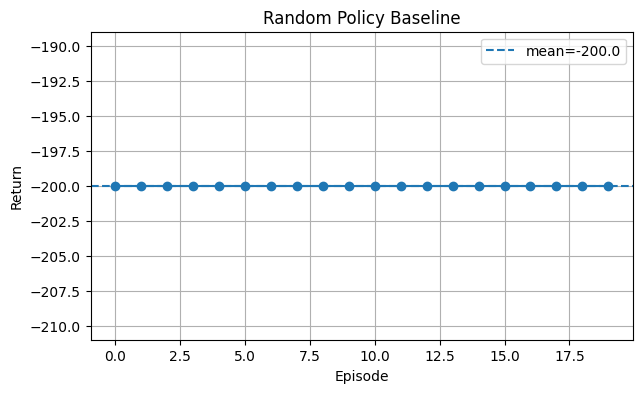

In [72]:
plt.figure(figsize=(7, 4))
plt.plot(random_returns, marker="o")
plt.axhline(random_mean, linestyle="--", label=f"mean={random_mean:.1f}")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Random Policy Baseline")
plt.legend()
plt.grid(True)
plt.show()


## 4. Replay buffer

In [73]:
class ReplayBuffer:
    """A simple FIFO replay buffer for DQN."""

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)

    def push(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        ##########################################################
        # TODO: Store one transition in the replay buffer.
        ##########################################################
        self.buffer.append((
            np.array(state, dtype=np.float32),
            np.array([action], dtype=np.long),
            np.array([reward], dtype=np.float32),
            np.array(next_state, dtype=np.float32),
            np.array([done], dtype=np.bool),
        ))

    def sample(self, batch_size: int, device: torch.device):
        ##########################################################
        # TODO: Randomly sample a minibatch and convert each component to a torch tensor.
        # Expected shapes:
        # states:      (batch_size, 2)
        # actions:     (batch_size, 1)
        # rewards:     (batch_size, 1)
        # next_states: (batch_size, 2)
        # dones:       (batch_size, 1)
        ##########################################################
        import random
        samples = random.sample(self.buffer, batch_size)

        def component_to_tensor(component: tuple[np.ndarray]):
            component = np.stack(component)
            return torch.as_tensor(component, device=device)
        
        states, actions, rewards, next_states, dones = list(map(component_to_tensor, zip(*samples)))
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        ##########################################################
        # TODO: Return the number of transitions currently stored.
        ##########################################################
        return len(self.buffer)


In [74]:
# Replay buffer shape check
buffer_test = ReplayBuffer(capacity=100)
env = make_env(seed=123)
state, _ = reset_env(env, seed=123)

for _ in range(40):
    action = env.action_space.sample()
    next_state, reward, done, info = step_env(env, action)
    buffer_test.push(state, action, reward, next_state, done)
    state = next_state
    if done:
        state, _ = reset_env(env)

states, actions, rewards, next_states, dones = buffer_test.sample(batch_size=32, device=device)

print(states.shape, actions.shape, rewards.shape, next_states.shape, dones.shape)

assert states.shape == (32, 2)
assert actions.shape == (32, 1)
assert rewards.shape == (32, 1)
assert next_states.shape == (32, 2)
assert dones.shape == (32, 1)

print("Replay buffer shape check passed.")
env.close()

torch.Size([32, 2]) torch.Size([32, 1]) torch.Size([32, 1]) torch.Size([32, 2]) torch.Size([32, 1])
Replay buffer shape check passed.


## 5. Q-network

In [75]:
class QNetwork(nn.Module):
    """MLP Q-network: state [position, velocity] -> three action values."""

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 64):
        super().__init__()
        ##########################################################
        # TODO: Define a small MLP and store it as self.net.
        # Suggested architecture:
        # Linear(state_dim, hidden_dim) -> ReLU ->
        # Linear(hidden_dim, hidden_dim) -> ReLU ->
        # Linear(hidden_dim, action_dim)
        ##########################################################
        self.relu = nn.ReLU()
        self.state_embed = nn.Linear(state_dim, hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ##########################################################
        # TODO: Return Q-values for all actions.
        ##########################################################
        x = self.relu(self.state_embed(x))
        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        return x

q_test = QNetwork(state_dim=2, action_dim=3).to(device)
dummy_states = torch.zeros(5, 2, device=device)
dummy_q_values = q_test(dummy_states)
assert dummy_q_values.shape == (5, 3)
print("Q-network output shape:", dummy_q_values.shape)


Q-network output shape: torch.Size([5, 3])


## 6. Exploration schedules and epsilon-greedy action selection

In [76]:
def exponential_epsilon_schedule(
    step: int,
    eps_start: float,
    eps_end: float,
    decay_steps: float,
) -> float:
    """Exponential epsilon decay."""
    return eps_end + (eps_start - eps_end) * np.exp(-step / decay_steps)


def less_exploration_schedule(step: int) -> float:
    """Exploration decreases relatively quickly and converges to 0.01."""
    return exponential_epsilon_schedule(
        step=step,
        eps_start=1.0,
        eps_end=0.01,
        decay_steps=1_000,
    )


def more_exploration_schedule(step: int) -> float:
    """Exploration remains higher for longer and converges to 0.05."""
    return exponential_epsilon_schedule(
        step=step,
        eps_start=1.0,
        eps_end=0.05,
        decay_steps=5_000,
    )


def select_action(
    q_net: QNetwork,
    state: np.ndarray,
    epsilon: float,
    action_dim: int,
    device: torch.device,
) -> int:
    """Epsilon-greedy action selection."""
    ##########################################################
    # TODO: With probability epsilon, choose a random action.
    # Otherwise, choose the action with the largest predicted Q-value.
    ##########################################################
    if random.random() < epsilon:
        action = random.randrange(3)
    else:
        state = torch.tensor(state, device=device)
        q_values = q_net(state)
        action = torch.argmax(q_values).item()

    return action

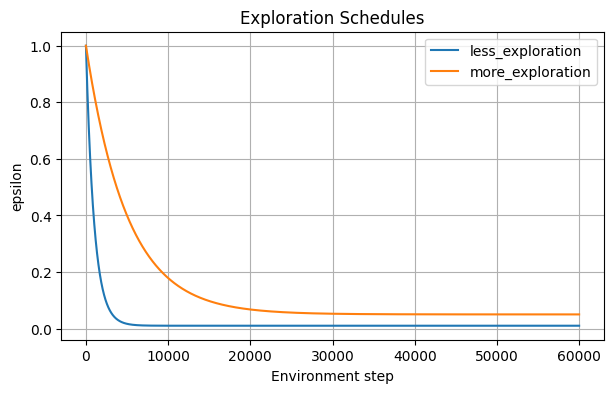

In [77]:
steps = np.arange(0, 60_000)
less_eps = [less_exploration_schedule(s) for s in steps]
more_eps = [more_exploration_schedule(s) for s in steps]

plt.figure(figsize=(7, 4))
plt.plot(steps, less_eps, label="less_exploration")
plt.plot(steps, more_eps, label="more_exploration")
plt.xlabel("Environment step")
plt.ylabel("epsilon")
plt.title("Exploration Schedules")
plt.legend()
plt.grid(True)
plt.show()


## 7. DQN loss and update

In [93]:
def compute_dqn_loss(
    q_net: QNetwork,
    target_q_net: QNetwork,
    batch,
    gamma: float,
) -> torch.Tensor:
    """Compute the standard DQN TD loss."""
    states, actions, rewards, next_states, dones = batch
    ##########################################################
    # TODO:
    # 1. Compute Q(s, a) for the actions stored in the replay buffer.
    # 2. Compute the DQN target using the target network:
    #    r + gamma * (1 - done) * max_a' Q_target(s', a')
    # 3. Return an MSE loss between Q(s, a) and the target.
    ##########################################################

    current_q_values = q_net(states).gather(1, actions)
    
    with torch.no_grad():
        next_q_values = target_q_net(next_states).max(dim=1, keepdim=True).values
        targets = rewards + gamma * (1. - dones.float()) * next_q_values
        targets = targets.to(current_q_values.dtype)

    return F.mse_loss(current_q_values, targets)


def dqn_update(
    q_net: QNetwork,
    target_q_net: QNetwork,
    optimizer: optim.Optimizer,
    replay_buffer: ReplayBuffer,
    batch_size: int,
    gamma: float,
    device: torch.device,
    grad_clip_norm: float | None = 10.0,
) -> float:
    """Sample a batch and perform one DQN gradient update."""
    ##########################################################
    # TODO:
    # 1. Sample a batch from the replay buffer.
    # 2. Compute the DQN loss.
    # 3. Run backpropagation and an optimizer step.
    # 4. Optionally clip gradients.
    # 5. Return the scalar loss value as a float.
    ##########################################################

    batch = replay_buffer.sample(batch_size, device)

    loss = compute_dqn_loss(q_net, target_q_net, batch, gamma)

    optimizer.zero_grad()
    loss.backward()

    if grad_clip_norm is not None:
        torch.nn.utils.clip_grad_norm_(q_net.parameters(), grad_clip_norm)

    optimizer.step()

    return float(loss.item())
    

**Implementation hints.**
- Use `torch.no_grad()` when computing the target-network value.
- Multiplying by `(1 - done)` removes bootstrapping after terminal transitions.
- `gather` is useful for selecting the Q-value corresponding to the action actually stored in the replay buffer.


## 8. Training loop

In [100]:
@dataclass
class DQNConfig:
    num_episodes: int = 400
    max_steps_per_episode: int = 200
    gamma: float = 0.99
    lr: float = 1e-3
    batch_size: int = 64
    buffer_capacity: int = 20_000
    warmup_steps: int = 1_000
    target_update_freq: int = 400
    train_freq: int = 1
    hidden_dim: int = 64


def train_dqn(
    seed: int,
    epsilon_fn: Callable[[int], float],
    config: DQNConfig,
    verbose: bool = True,
) -> Dict[str, List[float]]:
    """Train DQN for one random seed and one exploration schedule."""
    ##########################################################
    # TODO: Implement the DQN training loop.
    # Your implementation should:
    # 1. Set random seeds and create the environment.
    # 2. Initialize q_net, target_q_net, optimizer, and replay buffer.
    # 3. Interact with the environment using epsilon-greedy actions.
    # 4. Store transitions in the replay buffer.
    # 5. After warmup, periodically call dqn_update.
    # 6. Periodically copy q_net weights to target_q_net.
    # 7. Track episode returns, episode lengths, losses, epsilons, and success flags.
    # 8. Return a dictionary containing those results and the trained q_net state dict.
    ##########################################################

    set_seed(seed)
    env = make_env(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    hidden_dim = config.hidden_dim

    q_net = QNetwork(state_dim, action_dim, hidden_dim).to(device)

    target_q_net = QNetwork(state_dim, action_dim, hidden_dim).to(device)
    target_q_net.load_state_dict(q_net.state_dict())
    target_q_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=config.lr)
    replay_buffer = ReplayBuffer(config.buffer_capacity)

    seeds = []
    episode_returns = []
    episode_lengths = []
    success_flags = []
    losses = []
    epsilons = []
    global_step = 0

    for episode in range(config.num_episodes):
        state, info = reset_env(env, seed + episode)
        seeds.append(seed + episode)
        episode_return = 0.0
        episode_length = 0
        reached_goal = False

        for _ in range(config.max_steps_per_episode):
            epsilon = epsilon_fn(global_step)
            epsilons.append(epsilon)
            
            action = select_action(q_net, state, epsilon, action_dim, device)

            next_state, reward, done, info = step_env(env, action)

            replay_buffer.push(state, action, reward, next_state, done)

            episode_return += reward
            episode_length += 1
            reached_goal = reached_goal or bool(next_state[0] >= 0.5)

            state = next_state
            global_step += 1

            if (
                global_step >= config.warmup_steps
                and len(replay_buffer) >= config.batch_size
                and global_step % config.train_freq == 0
            ):
                loss = dqn_update(
                    q_net=q_net,
                    target_q_net=target_q_net,
                    optimizer=optimizer,
                    replay_buffer=replay_buffer,
                    batch_size=config.batch_size,
                    gamma=config.gamma,
                    device=device
                )
                losses.append(loss)

            if global_step % config.target_update_freq == 0:
                target_q_net.load_state_dict(q_net.state_dict())
            
            if done:
                break

        episode_returns.append(episode_return)
        episode_lengths.append(episode_length)
        success_flags.append(reached_goal)

    env.close()

    return {
        "seed": seed,
        "seeds": seeds,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "losses": losses,
        "epsilons": epsilons,
        "success_flags": success_flags,
        "q_net_state_dict": q_net.state_dict(),
    }

## 9. Run exploration-schedule ablation

The assignment requires exactly two exploration schedules and three random seeds per schedule:

- `less_exploration`: converges to epsilon `0.01` with `decay_steps=1_000`.
- `more_exploration`: converges to epsilon `0.05` with `decay_steps=5_000`.

Running all six experiments can take several minutes.
**For quick debugging, reduce `num_episodes` first, then restore it before collecting final results.**


In [95]:
SEEDS = [0, 1, 2]
SCHEDULES = {
    "less_exploration": less_exploration_schedule,
    "more_exploration": more_exploration_schedule,
}

config = DQNConfig(
    num_episodes=400,
    max_steps_per_episode=200,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20_000,
    warmup_steps=1_000,
    target_update_freq=400,
    train_freq=1,
    hidden_dim=64,
)

# To run the full ablation, execute this cell.
# Use the same config for both schedules so exploration is the only intended ablation variable.

all_results = {}

for schedule_name, eps_fn in SCHEDULES.items():
    all_results[schedule_name] = []
    print(f"\n=== Running schedule: {schedule_name} ===")

    for seed in SEEDS:
        result = train_dqn(
            seed=seed,
            epsilon_fn=eps_fn,
            config=config,
            verbose=True,
        )
        all_results[schedule_name].append(result)



=== Running schedule: less_exploration ===

=== Running schedule: more_exploration ===


## 10. Plot reward and loss curves

In [102]:
def moving_average(x: List[float], window: int = 20) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(x, kernel, mode="valid")


def sample_std(values) -> float:
    values = np.asarray(values, dtype=np.float32)
    if len(values) <= 1:
        return 0.0
    return float(np.std(values, ddof=1))


def make_final_return_table(all_results: Dict[str, List[dict]], last_k: int = 50) -> pd.DataFrame:
    """Return one row per schedule and seed."""
    rows = []
    for schedule_name, runs in all_results.items():
        for run in runs:
            returns = np.asarray(run["episode_returns"], dtype=np.float32)
            successes = np.asarray(run["success_flags"], dtype=np.float32)
            rows.append({
                "schedule": schedule_name,
                "seed": run["seed"],
                f"final_avg_return_last_{last_k}": float(np.mean(returns[-last_k:])),
                f"success_rate_last_{last_k}": float(np.mean(successes[-last_k:])),
            })
    return pd.DataFrame(rows)


def make_summary_table(final_table: pd.DataFrame, last_k: int = 50) -> pd.DataFrame:
    """Summarize final average return across the three seeds for each schedule."""
    return_col = f"final_avg_return_last_{last_k}"
    success_col = f"success_rate_last_{last_k}"
    rows = []

    for schedule_name, group in final_table.groupby("schedule", sort=False):
        rows.append({
            "schedule": schedule_name,
            "mean_final_return": float(group[return_col].mean()),
            "std_final_return": sample_std(group[return_col].values),
            "mean_success_rate": float(group[success_col].mean()),
            "std_success_rate": sample_std(group[success_col].values),
        })

    return pd.DataFrame(rows)


def plot_return_curves(all_results: Dict[str, List[dict]], window: int = 20):
    """Plot reward learning curves for every schedule and seed."""
    plt.figure(figsize=(9, 5))

    for schedule_name, runs in all_results.items():
        for run in runs:
            ma = moving_average(run["episode_returns"], window=window)
            x = np.arange(len(ma)) + (window - 1 if len(run["episode_returns"]) >= window else 0)
            plt.plot(x, ma, label=f"{schedule_name}, seed={run['seed']}", alpha=0.8)

    plt.xlabel("Episode")
    plt.ylabel(f"Return, moving average window={window}")
    plt.title("DQN MountainCar: Reward Curves for All Seeds")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_loss_curves(all_results: Dict[str, List[dict]], window: int = 200):
    """Plot loss curves for every schedule and seed."""
    plt.figure(figsize=(9, 5))

    for schedule_name, runs in all_results.items():
        for run in runs:
            losses = run["losses"]
            if len(losses) == 0:
                continue
            ma = moving_average(losses, window=window) if len(losses) >= window else np.asarray(losses, dtype=np.float32)
            x = np.arange(len(ma)) + (window - 1 if len(losses) >= window else 0)
            plt.plot(x, ma, label=f"{schedule_name}, seed={run['seed']}", alpha=0.8)

    plt.xlabel("Training update")
    plt.ylabel(f"Loss, moving average window={window}")
    plt.title("DQN MountainCar: Loss Curves for All Seeds")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_epsilon_curves(max_steps: int = 80_000):
    steps = np.arange(max_steps)
    plt.figure(figsize=(8, 5))
    for schedule_name, eps_fn in SCHEDULES.items():
        eps_values = [eps_fn(s) for s in steps]
        plt.plot(steps, eps_values, label=schedule_name)
    plt.xlabel("Environment step")
    plt.ylabel("epsilon")
    plt.title("Epsilon Schedules")
    plt.legend()
    plt.grid(True)
    plt.show()


Final average return over the last 50 episodes for each schedule and seed:


,schedule,seed,final_avg_return_last_50,success_rate_last_50
0,less_exploration,0,-134.860001,0.88
1,less_exploration,1,-194.460007,0.24
2,less_exploration,2,-142.539993,0.96
3,more_exploration,0,-157.500000,0.82
4,more_exploration,1,-200.000000,0.00
5,more_exploration,2,-152.919998,0.78


Summary across the three seeds for each schedule:


,schedule,mean_final_return,std_final_return,mean_success_rate,std_success_rate
0,less_exploration,-157.286667,32.421265,0.693333,0.394631
1,more_exploration,-170.139999,25.960716,0.533333,0.462313


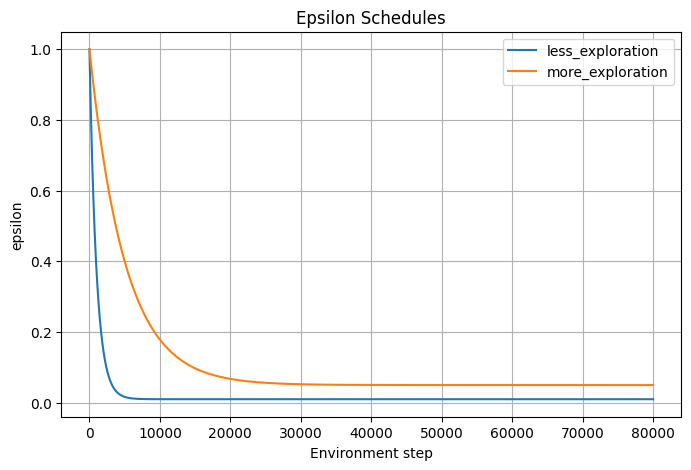

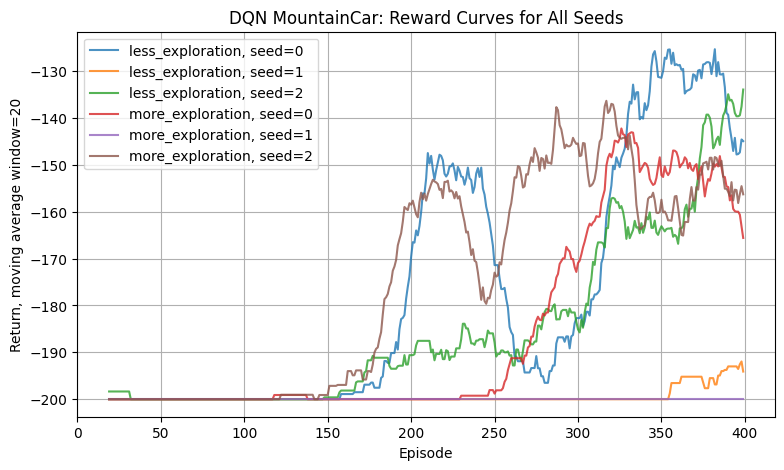

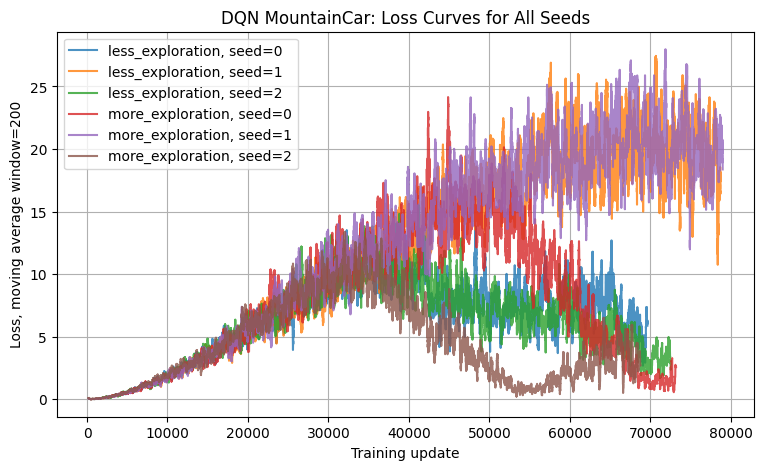

In [103]:
final_return_table = make_final_return_table(all_results, last_k=50)
summary_table = make_summary_table(final_return_table, last_k=50)

print("Final average return over the last 50 episodes for each schedule and seed:")
display(final_return_table)

print("Summary across the three seeds for each schedule:")
display(summary_table)

plot_epsilon_curves(max_steps=config.num_episodes * config.max_steps_per_episode)
plot_return_curves(all_results, window=20)
plot_loss_curves(all_results, window=200)


## 11. Evaluate a trained policy and inspect behavior

In [104]:
def load_trained_q_network(run: dict, hidden_dim: int = 64) -> QNetwork:
    q_net = QNetwork(state_dim=2, action_dim=3, hidden_dim=hidden_dim).to(device)
    q_net.load_state_dict(run["q_net_state_dict"])
    q_net.eval()
    return q_net


def evaluate_policy(
    q_net: QNetwork,
    seed: int = 10_000,
    num_episodes: int = 20,
):
    env = make_env(seed)
    returns = []
    lengths = []
    success_flags = []

    for ep in range(num_episodes):
        state, info = reset_env(env, seed + ep)
        done = False
        total_return = 0.0
        steps = 0
        reached_goal = False

        while not done:
            action = select_action(q_net, state, epsilon=0.0, action_dim=3, device=device)
            # During evaluation, set epsilon to 0 to select the optimal action greedily.
            next_state, reward, done, info = step_env(env, action)

            total_return += reward
            steps += 1
            reached_goal = reached_goal or bool(next_state[0] >= 0.5)
            state = next_state

        returns.append(total_return)
        lengths.append(steps)
        success_flags.append(reached_goal)

    env.close()
    return {
        "returns": returns,
        "lengths": lengths,
        "success_flags": success_flags,
    }


def collect_trajectory(q_net: QNetwork, seed: int = 20_000):
    env = make_env(seed)
    state, info = reset_env(env, seed)

    positions, velocities, actions = [], [], []
    rewards = []
    done = False

    while not done:
        positions.append(float(state[0]))
        velocities.append(float(state[1]))

        action = select_action(q_net, state, epsilon=0.0, action_dim=3, device=device)
        actions.append(action)

        next_state, reward, done, info = step_env(env, action)
        rewards.append(reward)
        state = next_state

    env.close()
    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "rewards": rewards,
    }

In [105]:
# Select the best run by final average return.
best_schedule = None
best_run = None
best_score = -1e9

for schedule_name, runs in all_results.items():
    for run in runs:
        score = np.mean(run["episode_returns"][-50:])
        if score > best_score:
            best_score = score
            best_schedule = schedule_name
            best_run = run

print("Best schedule:", best_schedule)
print("Best final avg return:", best_score)

best_q_net = load_trained_q_network(best_run, hidden_dim=config.hidden_dim)
eval_result = evaluate_policy(best_q_net, seed=12345, num_episodes=20)

print("Evaluation mean return:", np.mean(eval_result["returns"]))
print("Evaluation success rate:", np.mean(eval_result["success_flags"]))
print("Evaluation mean episode length:", np.mean(eval_result["lengths"]))

Best schedule: less_exploration
Best final avg return: -134.86
Evaluation mean return: -130.3
Evaluation success rate: 0.95
Evaluation mean episode length: 130.3


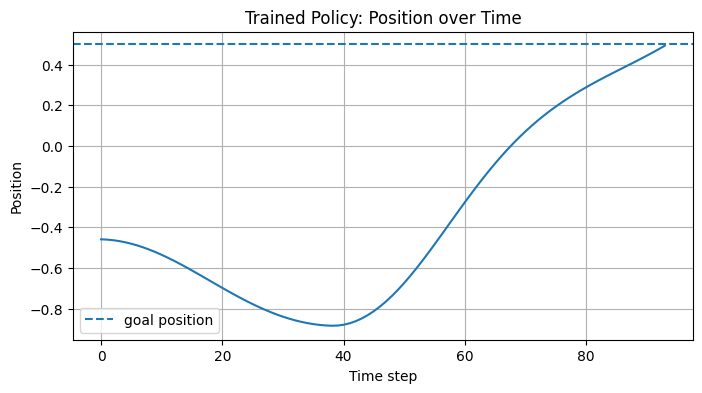

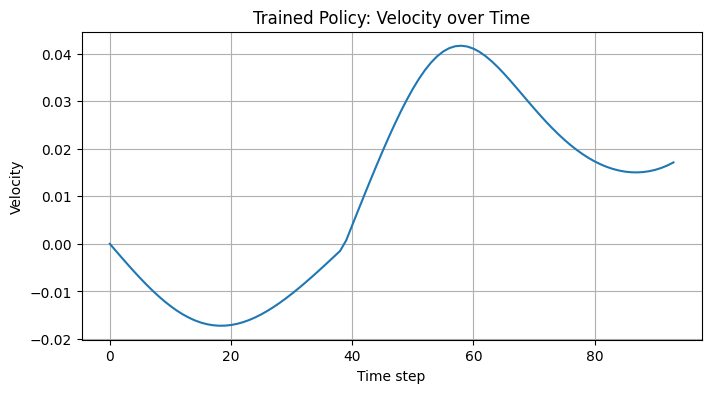

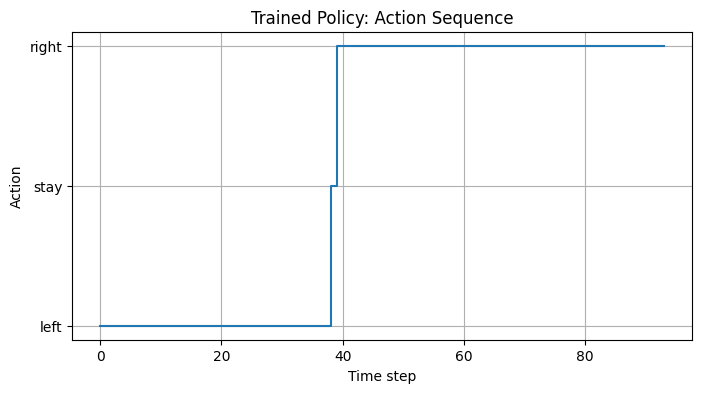

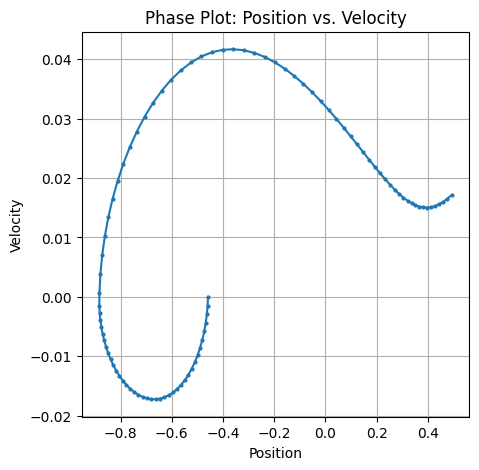

In [106]:
trajectory = collect_trajectory(best_q_net, seed=54321)

plt.figure(figsize=(8, 4))
plt.plot(trajectory["positions"])
plt.axhline(0.5, linestyle="--", label="goal position")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.title("Trained Policy: Position over Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(trajectory["velocities"])
plt.xlabel("Time step")
plt.ylabel("Velocity")
plt.title("Trained Policy: Velocity over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.step(np.arange(len(trajectory["actions"])), trajectory["actions"], where="post")
plt.yticks([0, 1, 2], ["left", "stay", "right"])
plt.xlabel("Time step")
plt.ylabel("Action")
plt.title("Trained Policy: Action Sequence")
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(trajectory["positions"], trajectory["velocities"], marker="o", markersize=2)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot: Position vs. Velocity")
plt.grid(True)
plt.show()

## 12. Sample-efficiency analysis and optional extension

The report must include a short analysis of **training speed / sample efficiency**. Here, sample efficiency means how much useful performance the agent obtains per environment interaction, for example:

- final return after a fixed number of episodes;
- the first episode where a moving-average return crosses a threshold such as `-150`;
- success rate over the last 50 episodes.

At minimum, analyze which parameters or techniques could improve sample efficiency. Good examples include learning rate, replay warmup size, target-network update frequency, batch size, network size, Double DQN, n-step returns, prioritized replay, state normalization, or carefully justified reward shaping. If you run an additional experiment, keep the comparison fair and clearly state what changed.


In [107]:
def first_reaching_episode(returns: List[float], threshold: float = -150.0, window: int = 20):
    """Return the first episode index where the moving-average return reaches a threshold."""
    ma = moving_average(returns, window=window)
    for idx, value in enumerate(ma):
        if value >= threshold:
            return idx + window - 1
    return None


def make_sample_efficiency_table(all_results: Dict[str, List[dict]], threshold: float = -150.0, window: int = 20) -> pd.DataFrame:
    rows = []
    for schedule_name, runs in all_results.items():
        for run in runs:
            rows.append({
                "schedule": schedule_name,
                "seed": run["seed"],
                "threshold": threshold,
                "window": window,
                "first_episode_reaching_threshold": first_reaching_episode(
                    run["episode_returns"], threshold=threshold, window=window
                ),
            })
    return pd.DataFrame(rows)


sample_efficiency_table = make_sample_efficiency_table(all_results, threshold=-150.0, window=20)
display(sample_efficiency_table)


,schedule,seed,threshold,window,first_episode_reaching_threshold
0,less_exploration,0,-150.0,20,210.0
1,less_exploration,1,-150.0,20,NaN
2,less_exploration,2,-150.0,20,373.0
3,more_exploration,0,-150.0,20,318.0
4,more_exploration,1,-150.0,20,NaN
5,more_exploration,2,-150.0,20,271.0


In [108]:
# Optional extension experiment for the report.
# Set this to True only if you want to run an extra sample-efficiency experiment.
# Keep the original required ablation results separate from this optional experiment.

run_optional_sample_efficiency_experiment = False

if run_optional_sample_efficiency_experiment:
    # TODO: Choose exactly what to change and justify it in the report.
    # Examples of possible changes include learning rate, warmup_steps, batch_size,
    # target_update_freq, hidden_dim, Double DQN, n-step returns, or prioritized replay.
    tuned_config = DQNConfig(
        num_episodes=400,
        max_steps_per_episode=200,
        gamma=0.99,
        lr=1e-3,
        batch_size=64,
        buffer_capacity=50_000,
        warmup_steps=1_000,
        target_update_freq=500,
        train_freq=1,
        hidden_dim=64,
    )

    tuned_results = {"your_method_name": []}
    for seed in SEEDS:
        tuned_results["your_method_name"].append(
            train_dqn(
                seed=seed,
                epsilon_fn=more_exploration_schedule,
                config=tuned_config,
                verbose=True,
            )
        )

    tuned_final_table = make_final_return_table(tuned_results, last_k=50)
    tuned_efficiency_table = make_sample_efficiency_table(tuned_results, threshold=-150.0, window=20)

    display(tuned_final_table)
    display(tuned_efficiency_table)
    plot_return_curves(tuned_results, window=20)
    plot_loss_curves(tuned_results, window=200)


## 13. Final discussion and report checklist

Write your final discussion in your own words. Your report should connect the plots and tables to the MountainCar dynamics and the exploration ablation.

### Required discussion questions

1. **Which exploration schedule performed better on average across the three seeds?**  
   Use the summary table, not only one seed.

3. **How do the reward curves and loss curves differ? Why is loss alone not enough to decide whether the learned policy is good?**

4. **In MountainCar, why can moving away from the goal initially be useful?**

5. **Briefly state whether and how you used AI tools.**  
   If you used AI tools, describe what you used them for.

6. **Sample-efficiency analysis.**  
   What parameters or techniques could improve training speed? If you ran an additional experiment, explain the exact change, show the result, and analyze whether it improved sample efficiency.

### Report checklist

The separate Word/PDF report should include:

- Student name and student ID. For a team submission, list both students' names and IDs.
- Random policy baseline mean and standard deviation.
- Reward curves for both schedules and all three seeds.
- Loss curves for both schedules and all three seeds.
- Final-return table over the last 50 episodes for every schedule/seed.
- Summary table with mean and standard deviation across seeds for each schedule.
- Answers to the required discussion questions.
- Sample-efficiency analysis, with optional extra experiment results if performed.
- AI-use disclosure.
